样本均值: 2.9388
样本方差: 1.9502
样本标准差: 1.3965

MLE估计均值: 2.9388, 与样本均值的误差: 0.0000e+00
MLE估计标准差: 1.3930, 与样本标准差的误差: 3.4956e-03


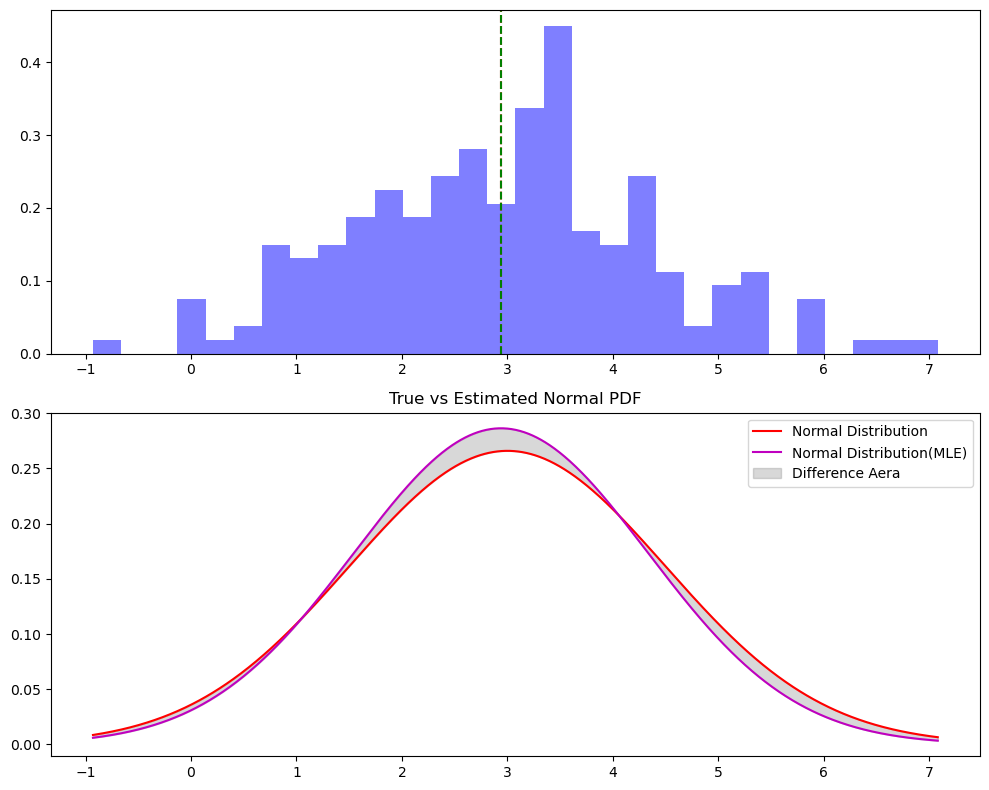

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

# 1.生成数据：从正态分布 N（mu=3,sigma=1.5）中生成 200 个样本
np.random.seed(42)
n=200
sample=np.random.normal(loc=3,scale=1.5,size=n)

# 2.计算统计量：输出样本均值、样本方差、样本标准差
sample_mu=np.mean(sample)
sample_var=np.var(sample,ddof=1)
sample_sigma=np.std(sample,ddof=1)

print(f"样本均值: {sample_mu:.4f}")
print(f"样本方差: {sample_var:.4f}")
print(f"样本标准差: {sample_sigma:.4f}")


# 3.MLE 估计：用 scipy.stats.norm.fit 估计 mu 和 sigma ，与真实值比较误差
mu_hat,sigma_hat=scipy.stats.norm.fit(sample)
diff_mu=abs(sample_mu-mu_hat)
diff_sigma=abs(sample_sigma-sigma_hat)
x=np.linspace(sample.min(),sample.max(),1000)
true_pdf=scipy.stats.norm.pdf(x,loc=3,scale=1.5)
MLE_pdf=scipy.stats.norm.pdf(x,loc=mu_hat,scale=sigma_hat)


print(f"\nMLE估计均值: {mu_hat:.4f}, 与样本均值的误差: {diff_mu:.4e}")
print(f"MLE估计标准差: {sigma_hat:.4f}, 与样本标准差的误差: {diff_sigma:.4e}")

# 4. 可视化：画出数据的直方图和拟合的正态分布曲线
plt.figure(figsize=(10,8))
plt.subplot(2,1,1)
plt.hist(sample,bins=30,alpha=0.5,color='b',label='Sample Histogram',density=True)
plt.axvline(x=sample_mu,color='r',linestyle='--',label='True_Mu')
plt.axvline(x=mu_hat,color='g',linestyle='--',label='MLE_Mu')
# plt.axhline(y=sample_sigma,color='b',linestyle='--',label='True_sigma')
# plt.axhline(y=sigma_hat,color='r',linestyle='--',label='MLE_sigma')

plt.subplot(2,1,2)
plt.plot(x,true_pdf,color='r',linestyle='-',label='Normal Distribution')
plt.plot(x,MLE_pdf,color='m',linestyle='-',label='Normal Distribution(MLE)')
plt.fill_between(x,true_pdf,MLE_pdf,color='gray',alpha=0.3,label='Difference Aera')

plt.legend()
plt.title('True vs Estimated Normal PDF')
plt.tight_layout()
plt.show()




## 补充知识点
1. plt.fill_between() 是Matplotlib 里用来填充两条水平曲线之间的区域的函数，非常适合用来画面积图、置信区域、误差带，或者对比两条曲线之间的差异区域

### 基础用法

```python
plt.fill_between(x, y1, y2, color='gray', alpha=0.3)
```
-  x ：横轴数据（和你画折线用的  x  完全一致）

-  y1 ：第一条曲线的纵轴数据

-  y2 ：第二条曲线的纵轴数据

-  color ：填充区域的颜色

-  alpha ：透明度（0-1，数值越小越透明，不会挡住背景的线条）

### 常见用法拓展
 
- 只填充特定条件的区域
 
比如只填充  true_pdf > mle_pdf  的部分：

``` python
plt.fill_between(x, true_pdf, mle_pdf, where=(true_pdf > mle_pdf), color='red', alpha=0.3)
plt.fill_between(x, true_pdf, mle_pdf, where=(true_pdf < mle_pdf), color='blue', alpha=0.3)
```

2. plt.tight_layout()  通俗讲解
 
一句话：自动调整整张图的布局，防止标题、坐标轴标签、图例互相重叠、被截断。

小补充
 
- 只写  plt.tight_layout()  就够用，不用传参数

- 顺序不能乱：先绘图 → 再  tight_layout()  → 最后  plt.show() 

- 单张图、多张子图都能用，是绘图里很常用的“防重叠”工具